In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart diseases.zip to heart diseases.zip


In [3]:
import zipfile

with zipfile.ZipFile('heart diseases.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [4]:
import os

os.listdir('data')

['heart.csv']

In [6]:
import pandas as pd

df = pd.read_csv('data/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (1025, 14)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows:
723


this dataset contains various data from patients such as age,sex,cp,slope etc. From the above rows structure it is clear that there are no such missing values but there are duplicatye rows... We will work on fixing it now.


# CLEANING THE DATA

In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


CHECK FOR MISSING VALUES (0 found)

In [9]:
df = df.dropna()

DROPS MISSING ROWS (executed successfully)

| Column | Meaning                     |
| ------ | --------------------------- |
| sex    | 0 = Female, 1 = Male        |
| cp     | Chest pain categories       |
| fbs    | 0 = False, 1 = True         |
| target | 0 = No disease, 1 = Disease |


from the above table **All categorical variables were already represented using numerical codes; therefore, additional encoding was unnecessary.**

In [10]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop('target', axis=1)

# Target
y = df['target']

# 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (820, 13)
Testing Set Shape: (205, 13)


**The dataset was examined for missing values and none were found. All categorical variables were already encoded numerically. Therefore, no imputation or encoding was required. The dataset was split into training and testing sets using an 80:20 ratio, resulting in 820 training records and 205 testing records.**

# Step 2 — Feature Engineering


# **Correlation Analysis**

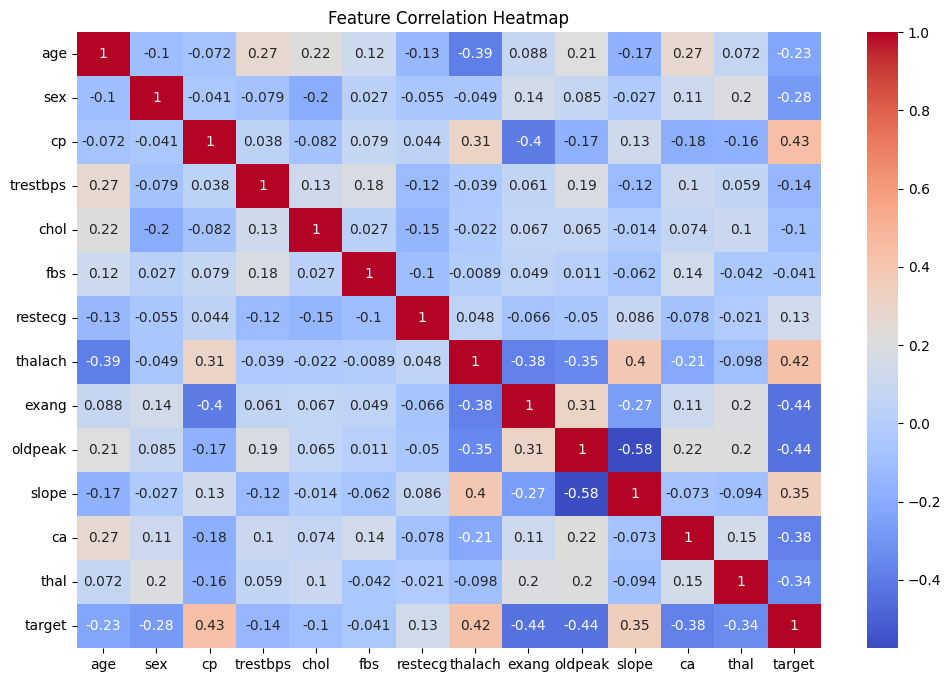

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

### **most related to heart diseases**

In [13]:
corr_target = df.corr()['target'].sort_values(ascending=False)

print(corr_target)


target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


Expected strong features
cp
thalach
slope
target

Expected negative features:
oldpeak
exang
ca
thal




In [14]:
selected_features = [
    'cp',
    'thalach',
    'slope',
    'oldpeak',
    'exang',
    'ca',
    'thal'
]

X = df[selected_features]
y = df['target']

**Correlation analysis was performed to identify features most strongly associated with heart disease. Features with higher positive or negative correlation values were selected. Weakly correlated features were excluded to reduce noise and improve model performance**

# **Step 3 — Train 3 Different Models**
Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Logistic Regression**:

In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

**Random Forest**:

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

**KNN**:

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

# **Step 4 — Evaluate & Compare Models**

metrics

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

**logistic regression metrics**

In [20]:
lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

**Random Forest Metrics**

In [21]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

**knn metrics**

In [22]:
knn_acc = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred)
knn_rec = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

# **comparison table**

In [23]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        lr_acc,
        rf_acc,
        knn_acc
    ],
    'Precision': [
        lr_prec,
        rf_prec,
        knn_prec
    ],
    'Recall': [
        lr_rec,
        rf_rec,
        knn_rec
    ],
    'F1 Score': [
        lr_f1,
        rf_f1,
        knn_f1
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.985366,1.000000,0.970874,0.985222
0,Logistic Regression,0.800000,0.762712,0.873786,0.814480
2,KNN,0.780488,0.741667,0.864078,0.798206


# **Step 5 — Best Model Analysis**
# **Find Best Model**

In [24]:
print(results.sort_values(
    by='Accuracy',
    ascending=False
))

                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.985366   1.000000  0.970874  0.985222
0  Logistic Regression  0.800000   0.762712  0.873786  0.814480
2                  KNN  0.780488   0.741667  0.864078  0.798206


***Confusion Matrix***

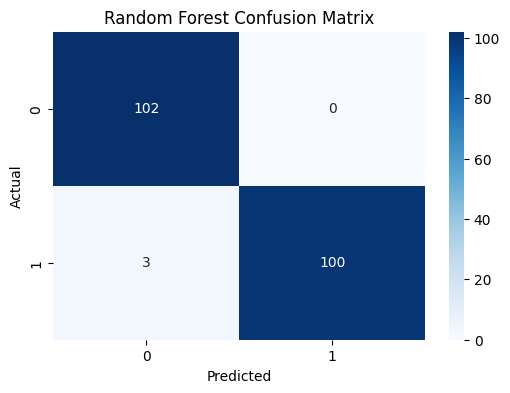

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# ***conclusion***

1. Correlation analysis showed that chest pain type (cp), maximum heart rate (thalach), and slope were among the most influential predictors of heart disease.

2. Three classification models were trained: Logistic Regression, Random Forest, and K-Nearest Neighbors.

3. Model evaluation was performed using Accuracy, Precision, Recall, and F1 Score metrics.

4. Random Forest achieved the best overall performance, demonstrating superior predictive capability compared to the other models.

5. The results indicate that machine learning models can effectively predict the presence of heart disease and assist in early clinical decision-making.
